<a href="https://colab.research.google.com/github/jyotifusion/energy_consume/blob/main/energycons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:

df1 = pd.read_csv("KwhConsumptionBlower78_1.csv")
df2 = pd.read_csv("KwhConsumptionBlower78_2.csv")
df3 = pd.read_csv("KwhConsumptionBlower78_3.csv")

df = pd.concat([df1, df2, df3])


In [ ]:
df.shape

(3606, 4)

In [ ]:
df.head()

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,76229,01 Jan 2022,16:55:52,1.010
1,76258,01 Jan 2022,21:45:29,0.908
2,76287,01 Jan 2022,12:24:52,0.926
3,76316,01 Jan 2022,04:07:36,0.928
4,76345,01 Jan 2022,06:52:25,0.916


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3606 entries, 0 to 1747
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   3606 non-null   int64  
 1   TxnDate      3606 non-null   object 
 2   TxnTime      3606 non-null   object 
 3   Consumption  3606 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 269.9+ KB


In [ ]:
df.describe()

,Unnamed: 0,Consumption
count,3606.000000,3606.000000
mean,29431.899334,2.781508
std,40122.323795,2.961248
min,0.000000,0.000000
25%,450.250000,0.948000
50%,1172.500000,1.032000
75%,78986.750000,4.005500
max,98038.000000,27.284000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
TxnDate,0
TxnTime,0
Consumption,0


In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.01)

df["anomaly"] = model.fit_predict(df[["Consumption"]])

In [ ]:
df["datetime"] = pd.to_datetime(df["TxnDate"] + " " + df["TxnTime"])


df = df.sort_values("datetime")

df = df[["datetime","Consumption"]]

In [ ]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["dayofweek"] = df["datetime"].dt.dayofweek

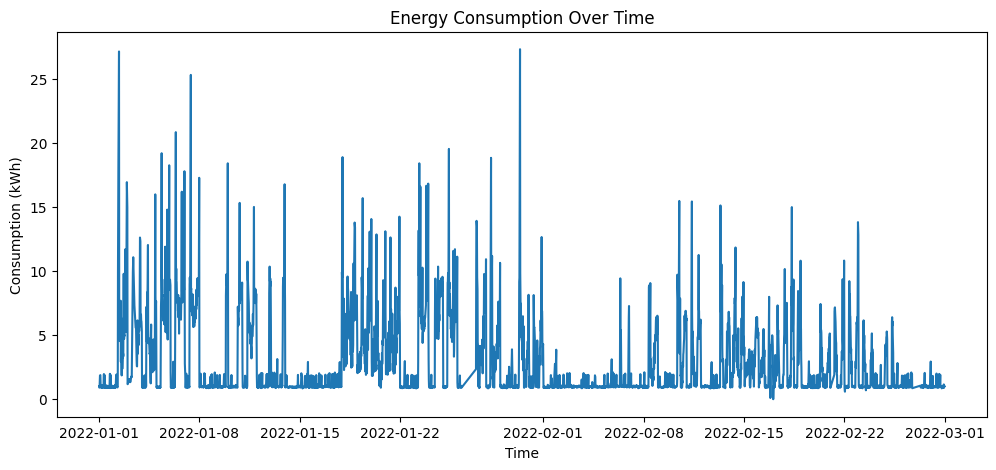

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["datetime"], df["Consumption"])
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")
plt.show()

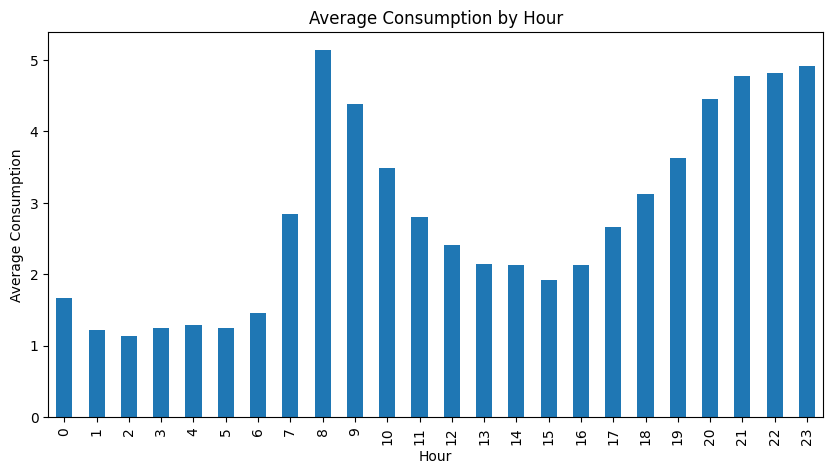

In [ ]:
hourly = df.groupby("hour")["Consumption"].mean()

plt.figure(figsize=(10,5))
hourly.plot(kind="bar")
plt.title("Average Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Consumption")
plt.show()

In [ ]:
X = df[["hour", "day", "month", "dayofweek"]]
y = df["Consumption"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
      )

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[1.32526067 0.93464    0.96943076 2.81384038 5.62847895 0.977195
 1.010096   1.012661   3.34105429 8.672603  ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 0.7597948878206282
Mean Squared Error: 2.896702499485659


In [ ]:
future_data = pd.DataFrame({
      "hour": [12],
      "day": [15],
      "month": [3],
      "dayofweek": [2]
 })

future_prediction = model.predict(future_data)

print("Predicted Consumption:", future_prediction)


Predicted Consumption: [2.01500333]


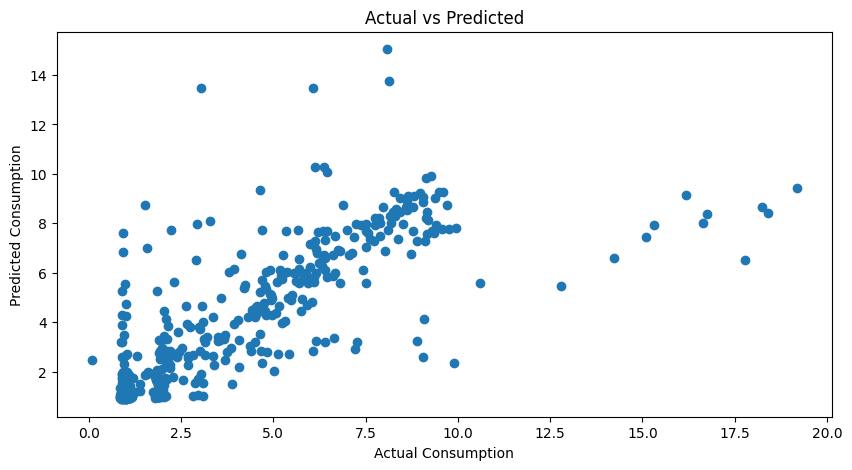

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption")
plt.title("Actual vs Predicted")
plt.show()